---

# Forecasting analysis: SARIMA vs ARIMAX

The following section loads the supplied final dataset and performs the forecasting research workflow.


# Armenia Inflation Forecasting — Data Cleaning and EDA




In [ ]:
from pathlib import Path
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf

## YoY inflation data

In [ ]:
cpi_raw = pd.read_csv(EDA_SOURCE_DIR / 'YoY_inflation.csv', sep='\t', engine='python', quoting=3)

In [ ]:
cpi_raw = pd.read_csv(EDA_SOURCE_DIR / 'YoY_inflation.csv', skiprows=1)

cpi_raw

       months  2010  Each month current year to similar month previous year  2011  Each month current year to similar month previous year  2012  Each month current year to similar month previous year  2013  Each month current year to similar month previous year  2014  Each month current year to similar month previous year  2015  Each month current year to similar month previous year  2016  Each month current year to similar month previous year  2017  Each month current year to similar month previous year  2018  Each month current year to similar month previous year  2019  Each month current year to similar month previous year  2020  Each month current year to similar month previous year  2021  Each month current year to similar month previous year  2022  Each month current year to similar month previous year  2023  Each month current year to similar month previous year  2024  Each month current year to similar month previous year  2025  Each month current year to similar month previous

In [ ]:
cpi_long = cpi_raw.melt(id_vars=['months'], var_name='year', value_name='yoy_index')
cpi_long

        months                                                          year yoy_index
0      January  2010  Each month current year to similar month previous year     107.0
1     February  2010  Each month current year to similar month previous year     109.4
2        March  2010  Each month current year to similar month previous year     108.8
3        April  2010  Each month current year to similar month previous year     106.8
4          May  2010  Each month current year to similar month previous year     106.3
5         June  2010  Each month current year to similar month previous year     105.8
6         July  2010  Each month current year to similar month previous year     107.8
7       August  2010  Each month current year to similar month previous year     109.6
8    September  2010  Each month current year to similar month previous year     108.6
9      October  2010  Each month current year to similar month previous year     109.1
10    November  2010  Each month current ye

In [ ]:
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}

cpi_long['month_num'] = cpi_long['months'].map(month_map)
cpi_long['year'] = cpi_long['year'].str[:4]
cpi_long.head()

     months  year yoy_index  month_num
0   January  2010     107.0          1
1  February  2010     109.4          2
2     March  2010     108.8          3
3     April  2010     106.8          4
4       May  2010     106.3          5

In [ ]:
cpi_long['ds'] = pd.to_datetime(
    cpi_long['year'].astype(str) + '-' +
    cpi_long['month_num'].astype(str) + '-01'
)

cpi_long = cpi_long.loc[:, ['ds', 'yoy_index']]

cpi_long.head()

          ds yoy_index
0 2010-01-01     107.0
1 2010-02-01     109.4
2 2010-03-01     108.8
3 2010-04-01     106.8
4 2010-05-01     106.3

In [ ]:
cpi_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ds         204 non-null    datetime64[ns]
 1   yoy_index  204 non-null    object        
dtypes: datetime64[ns](1), object(1)
memory usage: 3.3+ KB


In [ ]:
cpi_long['yoy_index'] = cpi_long['yoy_index'].astype(str).str.replace(',', '.')
cpi_long['yoy_index'] = pd.to_numeric(cpi_long['yoy_index'], errors='coerce')
cpi_long = cpi_long.assign(yoy_index=cpi_long['yoy_index'] - 100)
cpi_long.set_index("ds" , inplace=True)
cpi_long.head()

            yoy_index
ds                   
2010-01-01        7.0
2010-02-01        9.4
2010-03-01        8.8
2010-04-01        6.8
2010-05-01        6.3

## USD/AMD data

In [ ]:
amd_usd = pd.read_csv(EDA_SOURCE_DIR / 'AMD_USD (1).csv', index_col = False, parse_dates=['Ամսաթիվ'] , dayfirst=True).rename(columns = {'Ամսաթիվ':"ds"})
amd_usd['USD'] = pd.to_numeric(amd_usd['USD'])

amd_usd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4186 entries, 0 to 4185
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      4186 non-null   datetime64[ns]
 1   USD     4186 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 65.5 KB


In [ ]:
print(f"Check null values\n==========\n{amd_usd.isnull().sum()}")

print(print(f"Check dublicates\n==========\n{amd_usd.duplicated().sum()}"))

Check null values
ds     0
USD    0
dtype: int64
Check dublicates
0
None


In [ ]:
amd_usd.set_index("ds",inplace=True)
amd_usd = amd_usd.to_period(freq = "M").groupby("ds").agg({"USD":"mean"})
amd_usd = amd_usd.round(2)
amd_usd.index = amd_usd.index.to_timestamp()

In [ ]:
amd_usd.head()

               USD
ds                
2010-01-01  377.59
2010-02-01  380.49
2010-03-01  394.20
2010-04-01  394.53
2010-05-01  385.00

In [ ]:
amd_usd.tail()

               USD
ds                
2026-05-01  368.55
2026-06-01  368.26
2026-07-01  366.89
2026-08-01  365.48
2026-09-01  363.76

## Data_for_Project/Polycy_rate.csv

In [ ]:
rate = pd.read_csv(EDA_SOURCE_DIR / 'Polycy_rate.csv').rename(columns = {"Date":"ds"})

In [ ]:
rate.head()

           ds  Policy_Rate
0  2004-10-18         3.75
1  2005-01-10         4.50
2  2005-03-14         3.75
3  2005-08-10         3.00
4  2005-12-26         3.50

In [ ]:
rate["ds"] = pd.to_datetime(rate["ds"])

In [ ]:
rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ds           99 non-null     datetime64[ns]
 1   Policy_Rate  99 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.7 KB


In [ ]:
rate = rate.set_index("ds").sort_index()

In [ ]:
rate_monthly = rate.resample('MS').last().ffill()

rate_monthly = rate_monthly[rate_monthly.index >= '2010-01-01']

In [ ]:
rate_monthly.head()

            Policy_Rate
ds                     
2010-01-01         5.50
2010-02-01         6.00
2010-03-01         6.50
2010-04-01         7.00
2010-05-01         7.25

In [ ]:
rate_monthly.tail()

            Policy_Rate
ds                     
2026-05-01         6.50
2026-06-01         6.50
2026-07-01         6.50
2026-08-01         6.50
2026-09-01         6.75

## Oil 

In [ ]:
oil = pd.read_csv(EDA_SOURCE_DIR / 'DCOILBRENTEU.csv')
oil.head()

  observation_date  DCOILBRENTEU
0       2010-01-04         79.05
1       2010-01-05         79.27
2       2010-01-06         80.14
3       2010-01-07         80.57
4       2010-01-08         80.06

In [ ]:
oil = oil.rename(columns = {"observation_date" : "ds" , "DCOILBRENTEU" :"Brent"})
oil["ds"] = pd.to_datetime(oil["ds"])
oil["Brent"] = pd.to_numeric(oil["Brent"] , errors='coerce')

In [ ]:
oil.isnull().sum()

ds         0
Brent    132

In [ ]:
oil['Brent'] = oil['Brent'].ffill()

In [ ]:
oil.isnull().sum()

ds       0
Brent    0

In [ ]:
oil.set_index("ds",inplace = True)

In [ ]:
oil.head()

            Brent
ds               
2010-01-04  79.05
2010-01-05  79.27
2010-01-06  80.14
2010-01-07  80.57
2010-01-08  80.06

In [ ]:
oil = oil.to_period(freq = "M").to_timestamp()

In [ ]:
oil = oil.groupby(oil.index).agg({"Brent":"mean"})
oil = oil.round(2)

In [ ]:
oil.head()

            Brent
ds               
2010-01-01  76.20
2010-02-01  73.64
2010-03-01  78.83
2010-04-01  84.72
2010-05-01  75.81

## M2

In [ ]:
m2 = pd.read_excel(EDA_SOURCE_DIR / 'M2.xlsx')

In [ ]:
m2.head()

     value, month                        Unnamed: 1                         Unnamed: 2     Unnamed: 3                       Unnamed: 4     Unnamed: 5                             Unnamed: 6     Unnamed: 7
0  Activity value  Currency in circulation mln, AMD  Demand deposits in drams mln, AMD    M1 mln, AMD  Time deposits in drams mln, AMD    M2 mln, AMD  Deposits in foreign currency mln, AMD   M2X mln, AMD
1      2010-01-31                     252619.142656                       97377.747553  349996.890209                     62706.628273  412703.518482                          367121.699083  779825.217566
2      2010-02-28                     254158.086924                      103782.059483  357940.146407                     60324.779493    418264.9259                          380791.884452  799056.810352
3      2010-03-31                      247352.88379                       92920.772283  340273.656073                     60627.515137   400901.17121                          411372.51

In [ ]:
m2 = m2.loc[1:,["value, month" , "Unnamed: 5"]]
m2 = m2.rename(columns = {"value, month":"ds" , "Unnamed: 5" : "M2"})

In [ ]:
m2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199 entries, 1 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ds      199 non-null    object
 1   M2      199 non-null    object
dtypes: object(2)
memory usage: 3.2+ KB


In [ ]:
m2.duplicated().sum()

np.int64(0)

In [ ]:
m2.set_index("ds",inplace=True)
m2.index = pd.to_datetime(m2.index)
m2["M2"] = pd.to_numeric(m2["M2"])

In [ ]:
m2['M2_YoY'] = m2['M2'].pct_change(12) * 100

In [ ]:
m2 = m2.dropna()
m2.drop("M2" , axis = 1 , inplace=True)

In [ ]:
m2 = m2.round(2)

In [ ]:
m2.index = m2.index.to_period('M').to_timestamp()

In [ ]:
m2.head()

            M2_YoY
ds                
2011-01-01   16.74
2011-02-01   18.38
2011-03-01   26.76
2011-04-01   23.89
2011-05-01   26.47

## Final Dataset

In [ ]:
df = cpi_long.join(amd_usd,how = "inner").join(rate_monthly,how = "inner").join(m2 , how = "inner").join(oil , how = "inner").dropna()

df.head()

            yoy_index     USD  Policy_Rate  M2_YoY   Brent
ds                                                        
2011-01-01       10.3  364.95         7.25   16.74   96.59
2011-02-01       11.4  364.98         7.75   18.38  103.64
2011-03-01       11.5  368.42         8.25   26.76  114.64
2011-04-01        8.9  373.65         8.25   23.89  123.45
2011-05-01        9.0  374.25         8.25   26.47  114.98

In [ ]:
df['D_covid'] = ((df.index >= '2020-03-01') & (df.index <= '2021-12-01')).astype(int)
df['D_reloc'] = ((df.index >= '2022-03-01') & (df.index <= '2023-12-01')).astype(int)
df['D_oil_2026'] = ((df.index >= '2026-03-01') & (df.index <= '2026-09-01')).astype(int)
df['D_war'] = ((df.index >= '2020-09-01') & (df.index <= '2021-12-01')).astype(int)

df.to_csv(EDA_OUTPUT_PATH)

In [ ]:
df.head()

            yoy_index     USD  Policy_Rate  M2_YoY   Brent  D_covid  D_reloc  D_oil_2026  D_war
ds                                                                                             
2011-01-01       10.3  364.95         7.25   16.74   96.59        0        0           0      0
2011-02-01       11.4  364.98         7.75   18.38  103.64        0        0           0      0
2011-03-01       11.5  368.42         8.25   26.76  114.64        0        0           0      0
2011-04-01        8.9  373.65         8.25   23.89  123.45        0        0           0      0
2011-05-01        9.0  374.25         8.25   26.47  114.98        0        0           0      0

## EDA

In [ ]:
print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(df.info())
print("\nDescriptive Statistics:")
print(df.describe().round(2))

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 187 entries, 2011-01-01 to 2026-07-01
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   yoy_index    187 non-null    float64
 1   USD          187 non-null    float64
 2   Policy_Rate  187 non-null    float64
 3   M2_YoY       187 non-null    float64
 4   Brent        187 non-null    float64
 5   D_covid      187 non-null    int64  
 6   D_reloc      187 non-null    int64  
 7   D_oil_2026   187 non-null    int64  
 8   D_war        187 non-null    int64  
dtypes: float64(5), int64(4)
memory usage: 14.6 KB
None

Descriptive Statistics:
       yoy_index     USD  Policy_Rate  ...  D_reloc  D_oil_2026   D_war
count     187.00  187.00       187.00  ...   187.00      187.00  187.00
mean        3.32  437.82         7.45  ...     0.12        0.03    0.09
std         3.16   47.27         1.61  ...     0.32        0.16    0.28
min        -2.10  364.95     

In [ ]:
print("="*70)
print("DATA QUALITY CHECK")
print("="*70)
print(f"Missing values:\n{df.isnull().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")
print(f"\nPeriod: {df.index.min().date()} → {df.index.max().date()}")
print(f"Total observations: {len(df)}")

DATA QUALITY CHECK
Missing values:
yoy_index      0
USD            0
Policy_Rate    0
M2_YoY         0
Brent          0
D_covid        0
D_reloc        0
D_oil_2026     0
D_war          0
dtype: int64

Duplicates: 0

Period: 2011-01-01 → 2026-07-01
Total observations: 187


In [ ]:
df_corr = df.drop(columns=['D_covid', 'D_war', 'D_reloc', 'D_oil_2026'], errors='ignore')
corr = df_corr.corr()
print(corr.round(2))

             yoy_index   USD  Policy_Rate  M2_YoY  Brent
yoy_index         1.00 -0.22         0.28   -0.20   0.51
USD              -0.22  1.00        -0.41   -0.28  -0.67
Policy_Rate       0.28 -0.41         1.00   -0.45   0.35
M2_YoY           -0.20 -0.28        -0.45    1.00   0.14
Brent             0.51 -0.67         0.35    0.14   1.00


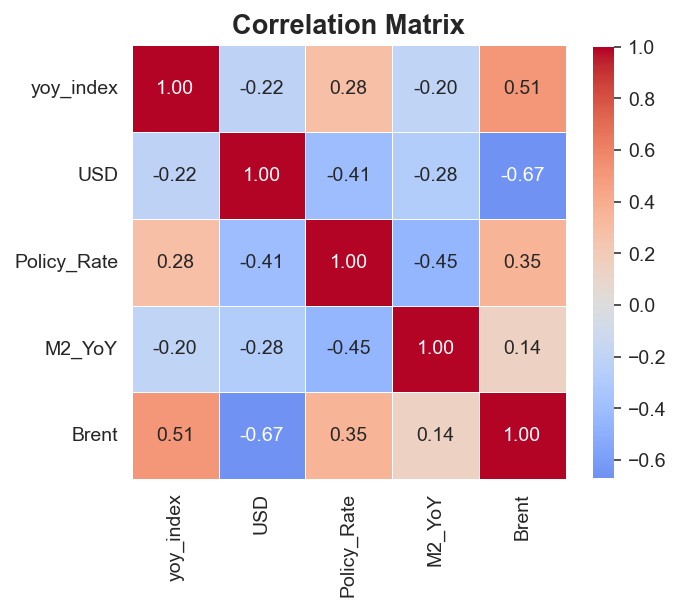

In [ ]:
plt.figure(figsize=(5, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

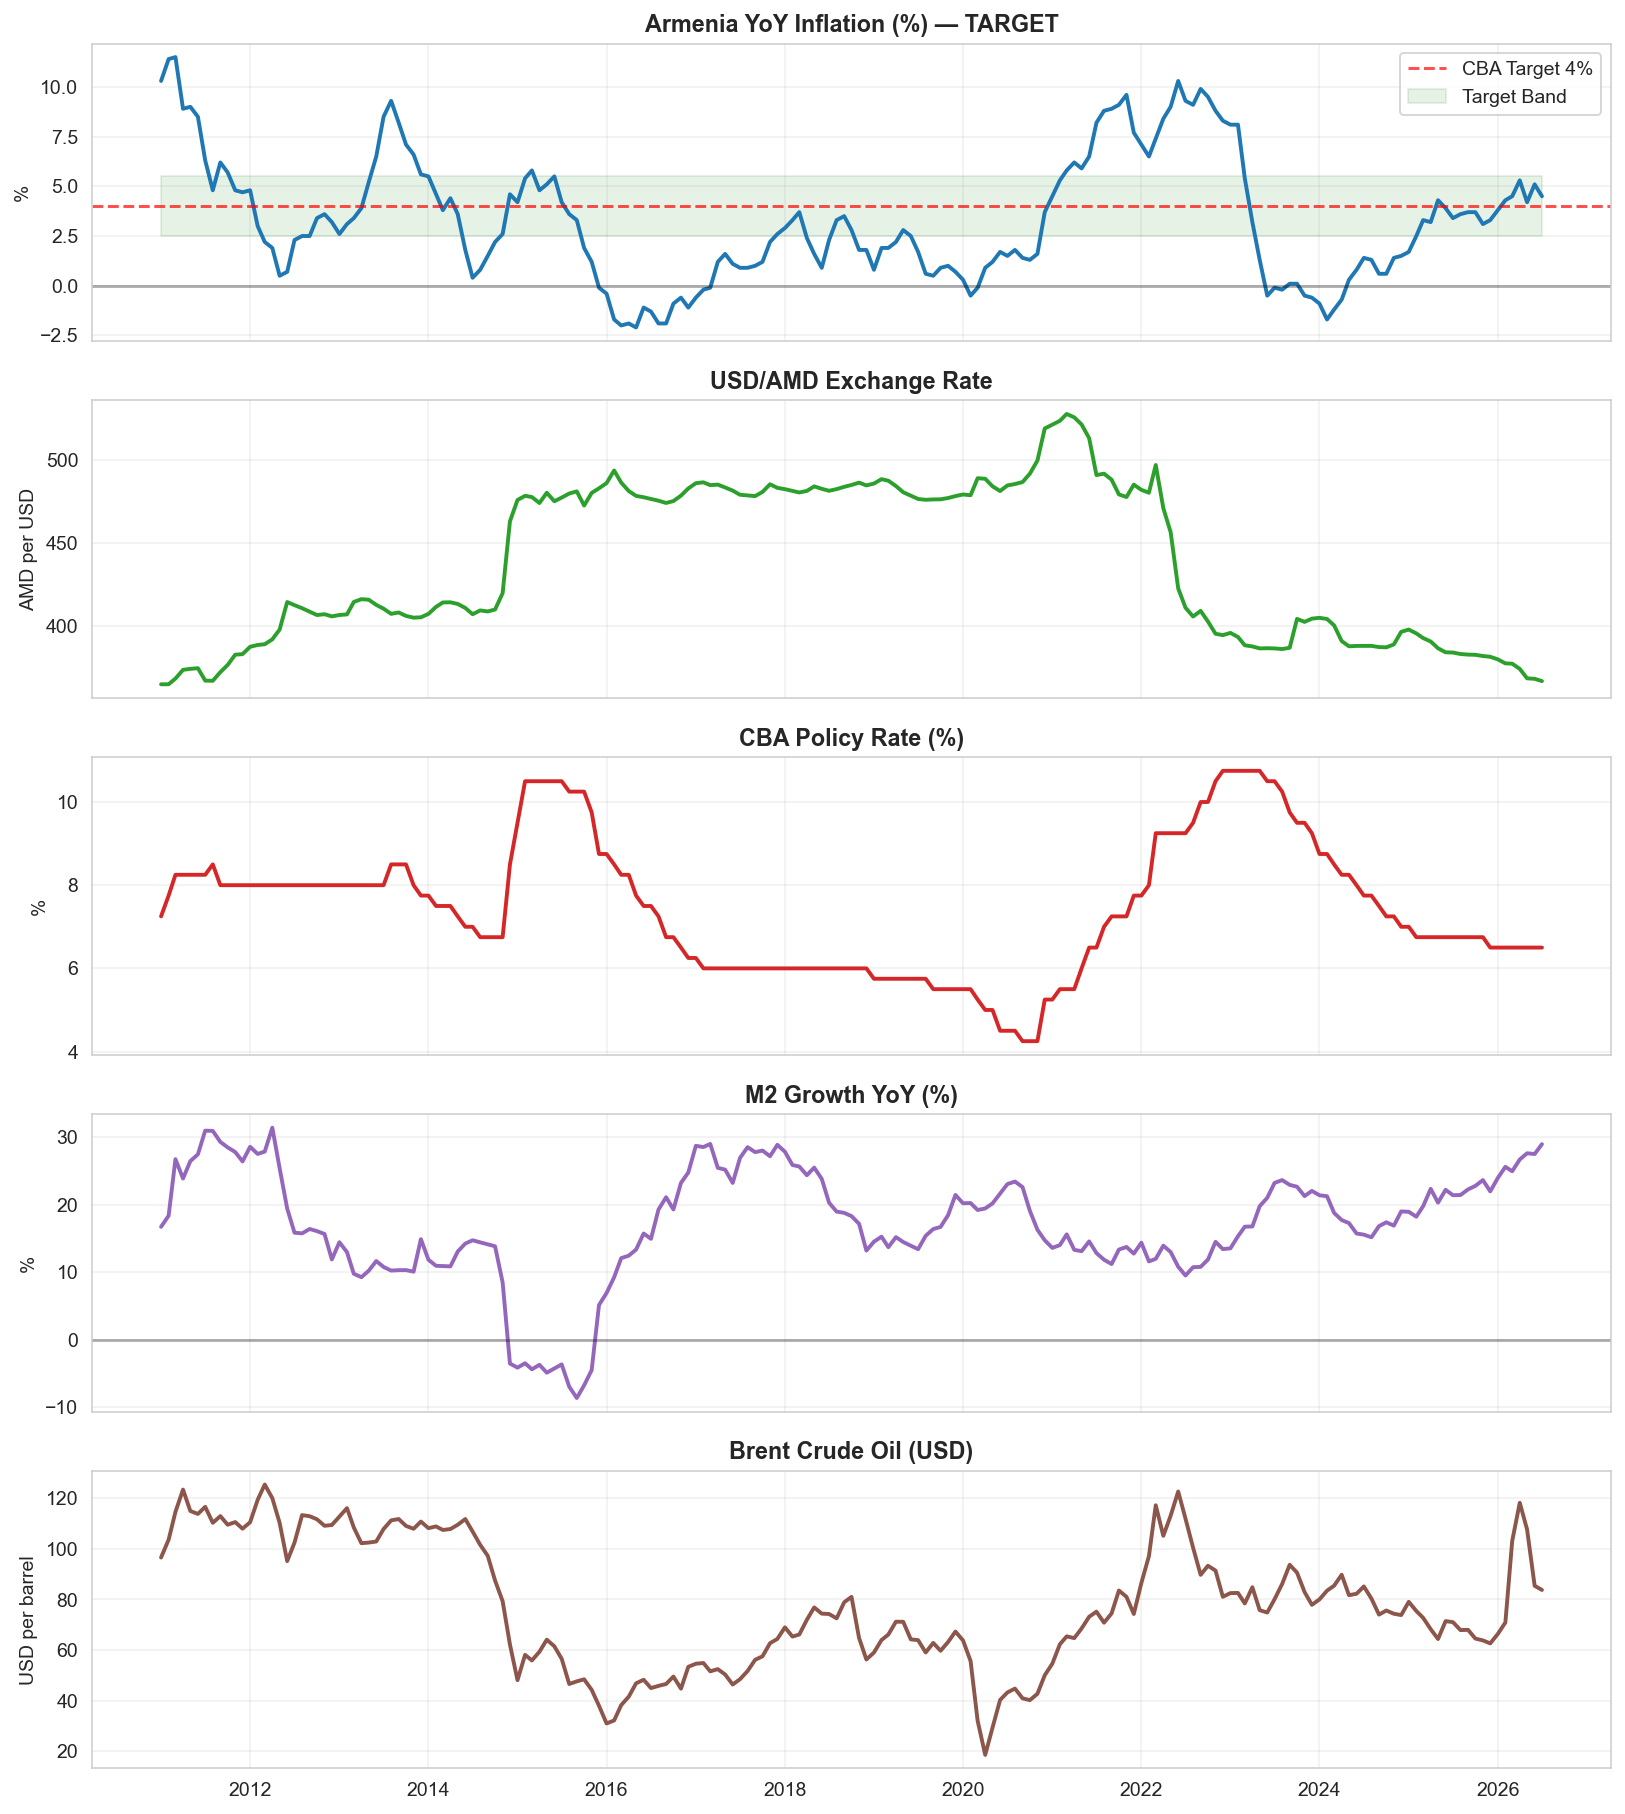

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

# 1. Inflation (Target)
axes[0].plot(df.index, df['yoy_index'], color='#1f77b4', linewidth=2)
axes[0].axhline(y=4, color='red', linestyle='--', alpha=0.7, label='CBA Target 4%')
axes[0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[0].fill_between(df.index, 2.5, 5.5, alpha=0.1, color='green', label='Target Band')
axes[0].set_title('Armenia YoY Inflation (%) — TARGET', fontsize=12, fontweight='bold')
axes[0].set_ylabel('%')
axes[0].legend(loc='upper right'); axes[0].grid(alpha=0.3)

# 2. Курс USD/AMD
axes[1].plot(df.index, df['USD'], color='#2ca02c', linewidth=2)
axes[1].set_title('USD/AMD Exchange Rate', fontsize=12, fontweight='bold')
axes[1].set_ylabel('AMD per USD')
axes[1].grid(alpha=0.3)

# 3. Ставка ЦБА
axes[2].plot(df.index, df['Policy_Rate'], color='#d62728', linewidth=2)
axes[2].set_title('CBA Policy Rate (%)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('%')
axes[2].grid(alpha=0.3)

# 4. M2 YoY
axes[3].plot(df.index, df['M2_YoY'], color='#9467bd', linewidth=2)
axes[3].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[3].set_title('M2 Growth YoY (%)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('%')
axes[3].grid(alpha=0.3)

# 5. Brent
axes[4].plot(df.index, df['Brent'], color='#8c564b', linewidth=2)
axes[4].set_title('Brent Crude Oil (USD)', fontsize=12, fontweight='bold')
axes[4].set_ylabel('USD per barrel')
axes[4].grid(alpha=0.3)

plt.savefig(Path.cwd() / 'outputs' / 'figures' / 'eda_overview.png', dpi=100, bbox_inches='tight')
plt.show()


# Armenia Inflation Forecasting: SARIMA vs ARIMAX


This research-grade, fully reproducible notebook evaluates whether contemporaneous macroeconomic and external information improves forecasts of Armenia's monthly YoY inflation beyond univariate models. It uses the supplied monthly dataset, a fixed final 24-month holdout, rolling-origin backtesting, and Diebold–Mariano tests.

**Main result.** On the 2024-08—2026-07 test set, SARIMA(0,1,2)×(0,0,1,12) outperformed ARIMAX: RMSE 0.974 versus 1.566 (MAE 0.805 versus 1.219). ARIMAX beat the Naive benchmark (DM p<0.001) but was significantly worse than SARIMA (DM p=0.008). In rolling-origin validation, SARIMA had the lowest RMSE at 6 and 12 months; ARIMAX was lowest at 1 month. Thus, the supplied macro/external set does not robustly improve this specification's medium-term inflation forecasts.

**Research question.** Can macroeconomic and external information improve the forecasting of inflation in Armenia beyond models based only on the historical dynamics of inflation?


## Context & methods

The target is monthly YoY CPI inflation (`yoy_index`, percent). The univariate benchmark is a SARIMA model; ARIMAX uses `FX_growth`, policy rate, M2 growth, Brent growth and the supplied structural-shock dummies. FX and Brent enter as monthly percentage changes after unit-root testing. All model comparisons are time-series based.

### Key assumptions

* The final holdout is the last 24 observations. After creating growth rates, the usable data begin in 2011-02; training ends in 2024-07 and the test begins in 2024-08.
* Grid search is conducted on the training target only, over `(p,d,q)∈{0,1,2}×{0,1}×{0,1,2}` and `(P,0,Q,12)`, where `P,Q∈{0,1}`. Seasonal differencing is not searched because the target is already a 12-month inflation rate; the selected SARIMA order is then used for ARIMAX.
* ARIMAX backtests use the realized future exogenous regressors. This is appropriate for measuring conditional explanatory forecasting value, but is an optimistic real-time forecast design unless exogenous paths can themselves be forecast or observed in advance.
* The 12-month scenario forecast holds policy rate and M2 growth at their final observed values; baseline FX and Brent monthly growth are zero. Scenario shocks occur in the first forecast month. The oil dummy remains active in August–September 2026, matching its supplied definition.


In [ ]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
ROOT = Path.cwd()
OUTPUT_DIR = ROOT / 'outputs'
FIG_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
SOURCE_PATH = Path(r'/Users/invoke/Desktop/Новая папка/final_dataset.csv')
assert SOURCE_PATH.exists(), f'Missing input file: {SOURCE_PATH}'
print('Input:', SOURCE_PATH)
print('Figures:', FIG_DIR)

Input: /Users/invoke/Desktop/Новая папка/final_dataset.csv
Figures: /Users/invoke/Documents/Codex/2026-09-19/project-armenia-inflation-forecasting-sarima-vs-3/outputs/figures


## 1. Load and validate the supplied final dataset

In [ ]:
raw = pd.read_csv(SOURCE_PATH, parse_dates=['ds'])
raw = raw.sort_values('ds').set_index('ds').asfreq('MS')
expected = ['yoy_index', 'USD', 'Policy_Rate', 'M2_YoY', 'Brent', 'D_covid', 'D_reloc', 'D_oil_2026', 'D_war']
assert raw.columns.tolist() == expected, raw.columns.tolist()
assert raw.index.is_monotonic_increasing
assert raw.index.duplicated().sum() == 0
assert raw.isna().sum().sum() == 0
assert len(raw) == 187
print('Shape:', raw.shape)
print('Range:', raw.index.min().strftime('%Y-%m'), 'to', raw.index.max().strftime('%Y-%m'))
display(raw.head(3))
print('Missing values:', int(raw.isna().sum().sum()), '| Duplicate timestamps:', int(raw.index.duplicated().sum()))

Shape: (187, 9)
Range: 2011-01 to 2026-07
Missing values: 0 | Duplicate timestamps: 0


            yoy_index     USD  Policy_Rate  M2_YoY   Brent  D_covid  D_reloc  D_oil_2026  D_war
ds                                                                                             
2011-01-01       10.3  364.95         7.25   16.74   96.59        0        0           0      0
2011-02-01       11.4  364.98         7.75   18.38  103.64        0        0           0      0
2011-03-01       11.5  368.42         8.25   26.76  114.64        0        0           0      0

## 2. Unit-root tests and transformations

In [ ]:
def stationarity_tests(series):
    series = series.dropna().astype(float)
    adf_stat, adf_p, adf_lags, adf_nobs, *_ = adfuller(series, autolag='AIC')
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, kpss_lags, _ = kpss(series, regression='c', nlags='auto')
    return {'ADF stat': adf_stat, 'ADF p-value': adf_p, 'ADF lags': adf_lags,
            'KPSS stat': kpss_stat, 'KPSS p-value': kpss_p, 'KPSS lags': kpss_lags,
            'ADF conclusion': 'stationary' if adf_p < 0.05 else 'non-stationary',
            'KPSS conclusion': 'stationary' if kpss_p >= 0.05 else 'non-stationary'}

level_vars = ['yoy_index', 'USD', 'Policy_Rate', 'M2_YoY', 'Brent']
level_tests = pd.DataFrame({v: stationarity_tests(raw[v]) for v in level_vars}).T
display(level_tests.round(4))

data = raw.copy()
data['FX_growth'] = data['USD'].pct_change() * 100
data['Brent_growth'] = data['Brent'].pct_change() * 100
growth_tests = pd.DataFrame({v: stationarity_tests(data[v]) for v in ['FX_growth', 'Brent_growth']}).T
display(growth_tests.round(4))

data = data.dropna().copy()
print('Usable sample after pct_change:', data.index.min().strftime('%Y-%m'), 'to', data.index.max().strftime('%Y-%m'), f'(n={len(data)})')

Usable sample after pct_change: 2011-02 to 2026-07 (n=186)


             ADF stat ADF p-value ADF lags KPSS stat KPSS p-value KPSS lags  ADF conclusion KPSS conclusion
yoy_index   -2.644508    0.084143       15  0.139044          0.1         9  non-stationary      stationary
USD         -1.373397    0.594962        1  0.445551     0.057521         9  non-stationary      stationary
Policy_Rate -2.351808    0.155803        3  0.186416          0.1         9  non-stationary      stationary
M2_YoY      -2.690826    0.075639       13  0.164676          0.1         9  non-stationary      stationary
Brent       -2.244457    0.190507        2  0.429401     0.064482         9  non-stationary      stationary

              ADF stat ADF p-value ADF lags KPSS stat KPSS p-value KPSS lags ADF conclusion KPSS conclusion
FX_growth     -9.38583         0.0        0  0.562681     0.027549         5     stationary  non-stationary
Brent_growth -9.402384         0.0        2  0.121906          0.1        10     stationary      stationary

**Interpretation rule.** ADF rejects its unit-root null at 5% when its p-value is below 0.05; KPSS fails to reject its stationarity null at 5% when its p-value is at least 0.05. Jointly, those results provide the strongest evidence of stationarity. Results that disagree are reported as mixed rather than force-classified.


## 3. Fixed train/test split and simple baselines

In [ ]:
n_test = 24
train = data.iloc[:-n_test].copy()
test = data.iloc[-n_test:].copy()
assert train.index.max() == pd.Timestamp('2024-07-01')
assert test.index.min() == pd.Timestamp('2024-08-01')
assert test.index.max() == pd.Timestamp('2026-07-01')

y_train, y_test = train['yoy_index'], test['yoy_index']
naive_fc = pd.Series(y_train.iloc[-1], index=test.index, name='Naive')
seasonal_history = pd.concat([y_train, y_test])
seasonal_naive_fc = pd.Series([seasonal_history.loc[d - pd.DateOffset(months=12)] for d in test.index], index=test.index, name='Seasonal Naive')

def score(actual, forecast):
    return {'MAE': mean_absolute_error(actual, forecast), 'RMSE': np.sqrt(mean_squared_error(actual, forecast))}

baseline_scores = pd.DataFrame({'Naive': score(y_test, naive_fc), 'Seasonal Naive': score(y_test, seasonal_naive_fc)}).T
print('Train:', train.index.min().strftime('%Y-%m'), 'to', train.index.max().strftime('%Y-%m'), f'(n={len(train)})')
print('Test: ', test.index.min().strftime('%Y-%m'), 'to', test.index.max().strftime('%Y-%m'), f'(n={len(test)})')
display(baseline_scores.round(3))

Train: 2011-02 to 2024-07 (n=162)
Test:  2024-08 to 2026-07 (n=24)


                  MAE   RMSE
Naive           1.942  2.238
Seasonal Naive  2.183  2.475

## 4. SARIMA order search, selection and diagnostics

In [ ]:
from itertools import product

orders = list(product(range(3), range(2), range(3)))
# Seasonal differencing is excluded because the target is YoY inflation; P and Q still
# allow a 12-month seasonal ARMA structure. This keeps the search focused and stable.
seasonal_orders = [(P, 0, Q, 12) for P, Q in product(range(2), range(2))]
search_rows = []
for order in orders:
    for seasonal_order in seasonal_orders:
        try:
            fit = SARIMAX(y_train, order=order, seasonal_order=seasonal_order,
                          trend='n', enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=120)
            search_rows.append({'order': order, 'seasonal_order': seasonal_order, 'AIC': fit.aic, 'BIC': fit.bic, 'n_params': len(fit.params), 'converged': fit.mle_retvals.get('converged', False)})
        except Exception as e:
            search_rows.append({'order': order, 'seasonal_order': seasonal_order, 'AIC': np.nan, 'BIC': np.nan, 'n_params': np.nan, 'converged': False, 'error': str(e)[:100]})

grid = pd.DataFrame(search_rows).dropna(subset=['AIC']).sort_values('AIC').reset_index(drop=True)
top10 = grid.head(10).copy()
display(top10.round(3))
min_aic = grid['AIC'].min()
near_aic = grid[grid['AIC'] <= min_aic + 2].copy()
selected_row = near_aic.sort_values(['BIC', 'n_params', 'AIC']).iloc[0]
SARIMA_ORDER = tuple(selected_row['order'])
SARIMA_SEASONAL_ORDER = tuple(selected_row['seasonal_order'])
print(f"Selected order: {SARIMA_ORDER} x {SARIMA_SEASONAL_ORDER} (AIC={selected_row['AIC']:.3f}, BIC={selected_row['BIC']:.3f}).")
print(f"Selection rule: lowest BIC among {len(near_aic)} model(s) within 2 AIC points of the minimum (minimum AIC={min_aic:.3f}).")

Selected order: (0, 1, 2) x (0, 0, 1, 12) (AIC=303.772, BIC=315.706).
Selection rule: lowest BIC among 3 model(s) within 2 AIC points of the minimum (minimum AIC=303.772).


       order seasonal_order      AIC      BIC  n_params  converged
0  (0, 1, 2)  (0, 0, 1, 12)  303.772  315.706         4       True
1  (1, 1, 2)  (0, 0, 1, 12)  305.413  320.331         5       True
2  (0, 1, 2)  (1, 0, 1, 12)  305.643  320.561         5       True
3  (2, 1, 2)  (0, 0, 1, 12)  306.326  324.228         6       True
4  (1, 1, 0)  (0, 0, 1, 12)  306.743  315.734         3       True
5  (1, 1, 2)  (1, 0, 1, 12)  307.211  325.113         6       True
6  (0, 1, 1)  (0, 0, 1, 12)  307.289  316.261         3       True
7  (1, 1, 1)  (0, 0, 1, 12)  307.651  319.613         4       True
8  (2, 1, 2)  (1, 0, 1, 12)  308.067  328.953         7       True
9  (1, 1, 0)  (1, 0, 1, 12)  308.260  320.249         4       True

                                      SARIMAX Results                                       
Dep. Variable:                            yoy_index   No. Observations:                  162
Model:             SARIMAX(0, 1, 2)x(0, 0, [1], 12)   Log Likelihood                -147.886
Date:                              Sat, 19 Sep 2026   AIC                            303.772
Time:                                      18:58:46   BIC                            315.706
Sample:                                  02-01-2011   HQIC                           308.621
                                       - 07-01-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.3687      0.088      4.211      0.000       0.197       0.540
ma.L2          0.09

                 test  statistic  p_value                         null
0  Ljung-Box (lag 12)     8.6084   0.7360  no residual autocorrelation
1  Ljung-Box (lag 24)    21.2206   0.6257  no residual autocorrelation
2         Jarque-Bera     9.2391   0.0099             normal residuals
3   ARCH LM (12 lags)    11.7301   0.4676      homoskedastic residuals

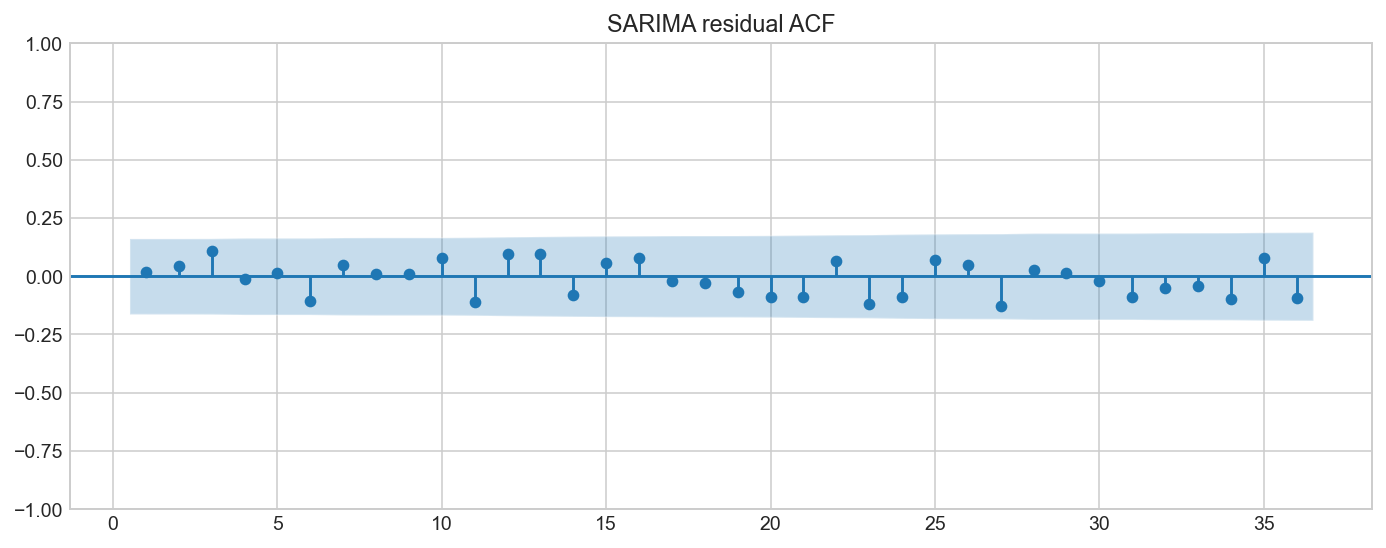

In [ ]:
sarima_fit = SARIMAX(y_train, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER,
                     trend='n', enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=500)
print(sarima_fit.summary())

resid = sarima_fit.resid.iloc[sarima_fit.loglikelihood_burn:].dropna()
lb = acorr_ljungbox(resid, lags=[12, 24], return_df=True)
jb_stat, jb_p, skew, kurt = jarque_bera(resid)
arch_stat, arch_p, _, _ = het_arch(resid, nlags=12)
diagnostics = pd.DataFrame({
    'test': ['Ljung-Box (lag 12)', 'Ljung-Box (lag 24)', 'Jarque-Bera', 'ARCH LM (12 lags)'],
    'statistic': [lb.loc[12, 'lb_stat'], lb.loc[24, 'lb_stat'], jb_stat, arch_stat],
    'p_value': [lb.loc[12, 'lb_pvalue'], lb.loc[24, 'lb_pvalue'], jb_p, arch_p],
    'null': ['no residual autocorrelation', 'no residual autocorrelation', 'normal residuals', 'homoskedastic residuals']
})
display(diagnostics.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid, lags=36, ax=ax, zero=False)
ax.set_title('SARIMA residual ACF')
fig.tight_layout()
fig.savefig(FIG_DIR / 'sarima_residual_acf.png', dpi=180, bbox_inches='tight')
plt.show()

          MAE   RMSE
SARIMA  0.805  0.974

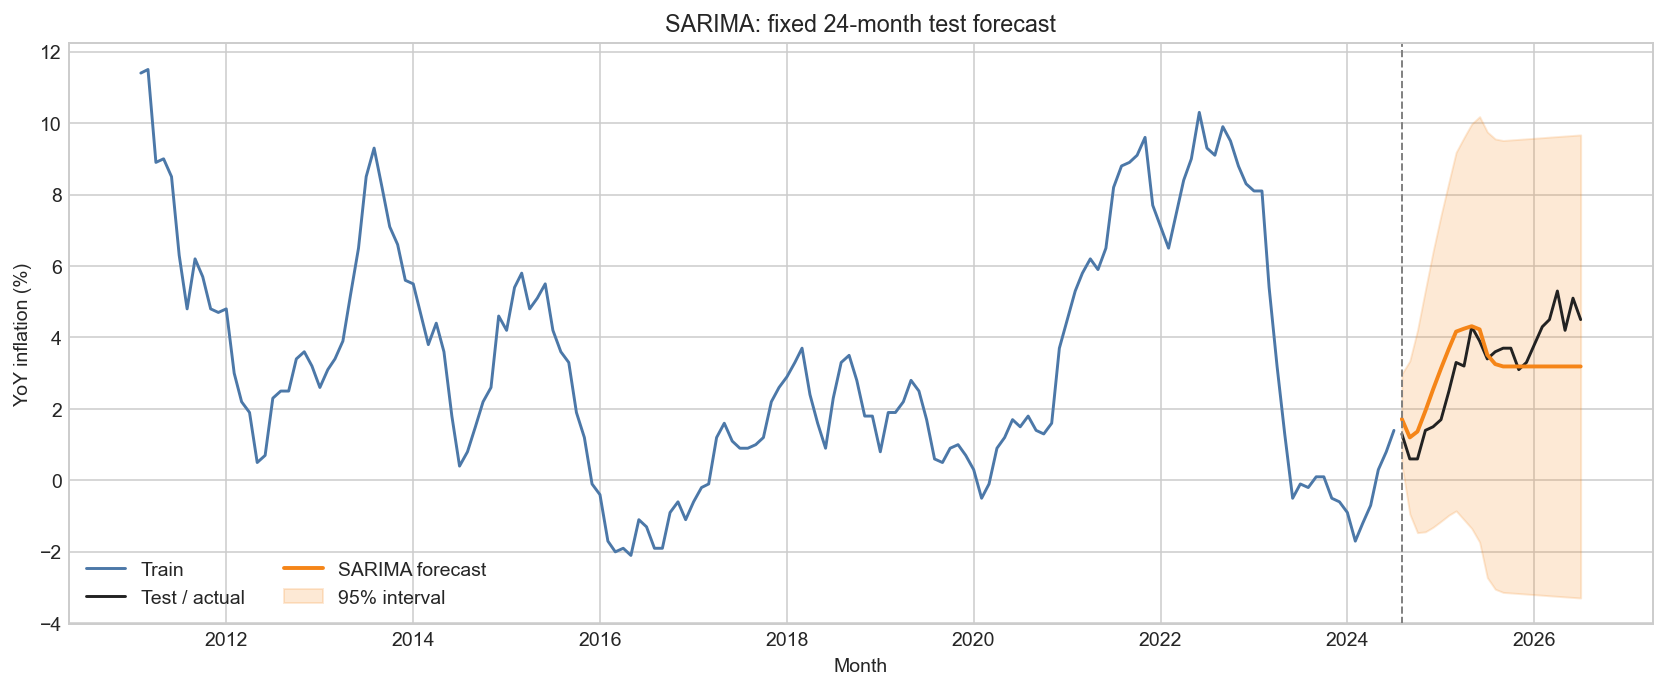

In [ ]:
sarima_pred = sarima_fit.get_forecast(steps=len(test))
sarima_fc = sarima_pred.predicted_mean.rename('SARIMA')
sarima_ci95 = sarima_pred.conf_int(alpha=0.05)
sarima_scores = pd.DataFrame({'SARIMA': score(y_test, sarima_fc)}).T
display(sarima_scores.round(3))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_train.index, y_train, color='#4C78A8', label='Train')
ax.plot(y_test.index, y_test, color='#222222', label='Test / actual')
ax.plot(sarima_fc.index, sarima_fc, color='#F58518', lw=2, label='SARIMA forecast')
ax.fill_between(sarima_fc.index, sarima_ci95.iloc[:, 0].astype(float), sarima_ci95.iloc[:, 1].astype(float), color='#F58518', alpha=0.18, label='95% interval')
ax.axvline(test.index.min(), color='grey', ls='--', lw=1)
ax.set(title='SARIMA: fixed 24-month test forecast', ylabel='YoY inflation (%)', xlabel='Month')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / 'sarima_test_forecast.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. ARIMAX with macroeconomic, external and shock regressors

In [ ]:
exog_cols = ['FX_growth', 'Policy_Rate', 'M2_YoY', 'Brent_growth', 'D_covid', 'D_war', 'D_reloc', 'D_oil_2026']
X_train, X_test = train[exog_cols], test[exog_cols]
arimax_fit = SARIMAX(y_train, exog=X_train, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER,
                     trend='n', enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=500)
print(arimax_fit.summary())

coef_table = pd.DataFrame({
    'coefficient': arimax_fit.params,
    'std_error': arimax_fit.bse,
    'p_value': arimax_fit.pvalues
})
coef_table['significant_5pct'] = coef_table['p_value'] < 0.05
display(coef_table.round(4))

                                      SARIMAX Results                                       
Dep. Variable:                            yoy_index   No. Observations:                  162
Model:             SARIMAX(0, 1, 2)x(0, 0, [1], 12)   Log Likelihood                -140.298
Date:                              Sat, 19 Sep 2026   AIC                            304.597
Time:                                      18:58:47   BIC                            340.400
Sample:                                  02-01-2011   HQIC                           319.144
                                       - 07-01-2024                                         
Covariance Type:                                opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
FX_growth       -0.0122      0.018     -0.669      0.504      -0.048       0.024
Policy_Rate  

              coefficient  std_error  p_value  significant_5pct
FX_growth         -0.0122     0.0183   0.5036             False
Policy_Rate       -0.0467     0.1376   0.7342             False
M2_YoY            -0.1074     0.0326   0.0010              True
Brent_growth      -0.0002     0.0028   0.9453             False
D_covid            0.4100     0.8670   0.6363             False
D_war              0.0965     0.3838   0.8015             False
D_reloc           -0.0238     0.6700   0.9716             False
D_oil_2026         0.0000     0.0000   1.0000             False
ma.L1              0.2986     0.0943   0.0015              True
ma.L2              0.1066     0.0960   0.2670             False
ma.S.L12          -0.8895     0.1376   0.0000              True
sigma2             0.3546     0.0536   0.0000              True

                  MAE   RMSE
SARIMA          0.805  0.974
ARIMAX          1.219  1.566
Naive           1.942  2.238
Seasonal Naive  2.183  2.475

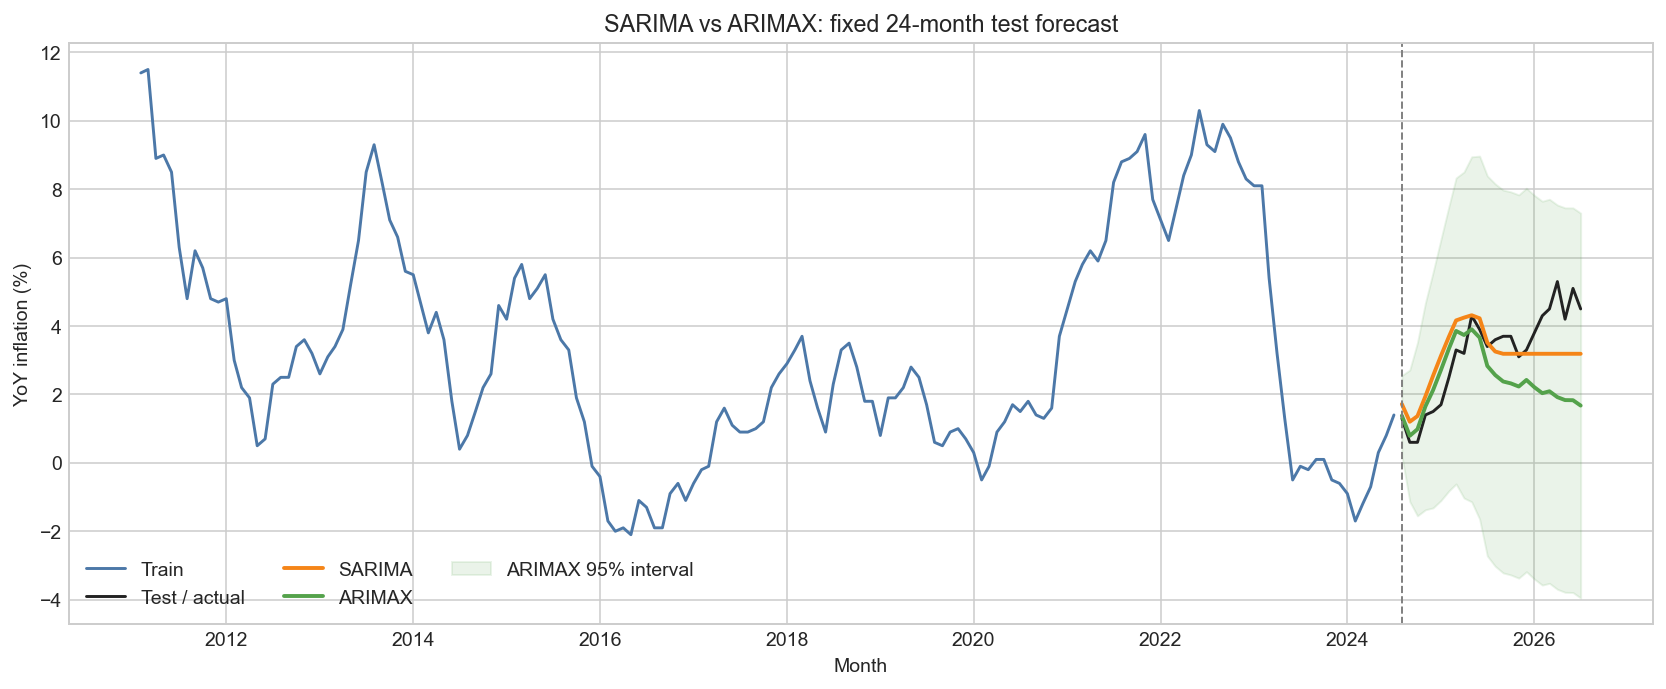

In [ ]:
arimax_pred = arimax_fit.get_forecast(steps=len(test), exog=X_test)
arimax_fc = arimax_pred.predicted_mean.rename('ARIMAX')
arimax_ci95 = arimax_pred.conf_int(alpha=0.05)
arimax_scores = pd.DataFrame({'ARIMAX': score(y_test, arimax_fc)}).T
comparison = pd.concat([baseline_scores, sarima_scores, arimax_scores]).sort_values('RMSE')
display(comparison.round(3))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_train.index, y_train, color='#4C78A8', label='Train')
ax.plot(y_test.index, y_test, color='#222222', label='Test / actual')
ax.plot(sarima_fc.index, sarima_fc, color='#F58518', lw=2, label='SARIMA')
ax.plot(arimax_fc.index, arimax_fc, color='#54A24B', lw=2, label='ARIMAX')
ax.fill_between(arimax_fc.index, arimax_ci95.iloc[:, 0].astype(float), arimax_ci95.iloc[:, 1].astype(float), color='#54A24B', alpha=0.12, label='ARIMAX 95% interval')
ax.axvline(test.index.min(), color='grey', ls='--', lw=1)
ax.set(title='SARIMA vs ARIMAX: fixed 24-month test forecast', ylabel='YoY inflation (%)', xlabel='Month')
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'model_comparison_test_forecast.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Rolling-origin backtesting

Origins: 2024-07 through 2025-06 (n=12); each origin forecasts 12 months ahead.


                MAE h=1  MAE h=3  MAE h=6  MAE h=12  RMSE h=1  RMSE h=3  RMSE h=6  RMSE h=12
model                                                                                       
ARIMAX            0.292    0.583    0.868     1.835     0.372     0.667     1.053      2.047
Naive             0.467    0.900    1.467     1.875     0.585     1.062     1.733      2.033
SARIMA            0.388    0.586    0.770     0.988     0.480     0.645     0.884      1.219
Seasonal Naive    2.567    2.850    3.025     1.875     2.890     3.064     3.164      2.033

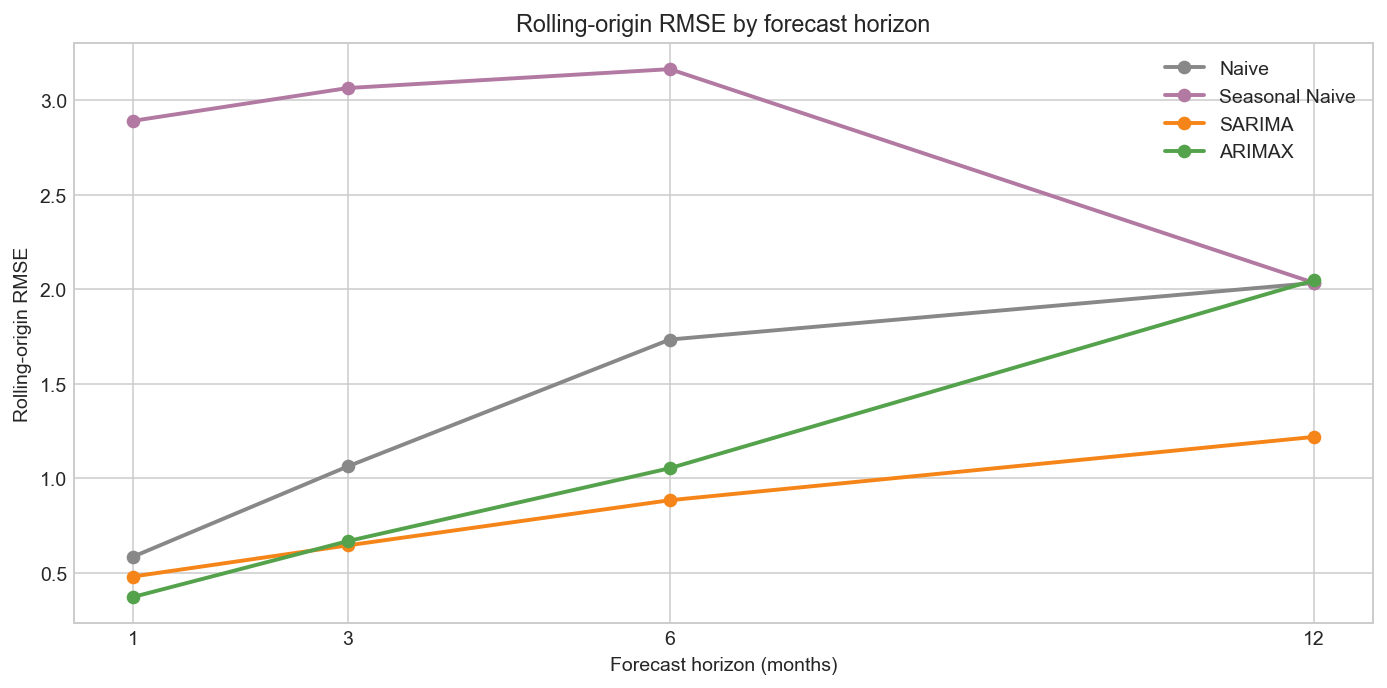

In [ ]:
HORIZONS = [1, 3, 6, 12]
initial_origin = pd.Timestamp('2024-07-01')
last_origin = data.index.max() - pd.DateOffset(months=13)
origins = pd.date_range(initial_origin, last_origin, freq='MS')
assert len(origins) == 12

records = []
for origin in origins:
    rolling_train = data.loc[:origin]
    future_idx = pd.date_range(origin + pd.DateOffset(months=1), periods=12, freq='MS')
    actual = data.loc[future_idx, 'yoy_index']
    r_sarima = SARIMAX(rolling_train['yoy_index'], order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER,
                       trend='n', enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=150)
    r_arimax = SARIMAX(rolling_train['yoy_index'], exog=rolling_train[exog_cols], order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER,
                       trend='n', enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=150)
    r_sarima_fc = r_sarima.get_forecast(steps=12).predicted_mean
    r_arimax_fc = r_arimax.get_forecast(steps=12, exog=data.loc[future_idx, exog_cols]).predicted_mean
    for h in HORIZONS:
        target_date = future_idx[h-1]
        y_actual = actual.loc[target_date]
        seasonal = data.loc[target_date - pd.DateOffset(months=12), 'yoy_index']
        predictions = {'Naive': rolling_train['yoy_index'].iloc[-1], 'Seasonal Naive': seasonal,
                       'SARIMA': r_sarima_fc.loc[target_date], 'ARIMAX': r_arimax_fc.loc[target_date]}
        for model, pred in predictions.items():
            records.append({'origin': origin, 'target_date': target_date, 'horizon': h, 'model': model,
                            'actual': y_actual, 'forecast': pred, 'error': y_actual - pred})

rolling = pd.DataFrame(records)
rolling_summary = rolling.groupby(['horizon', 'model']).agg(
    MAE=('error', lambda x: np.mean(np.abs(x))), RMSE=('error', lambda x: np.sqrt(np.mean(np.square(x)))), n=('error', 'size')
).reset_index().pivot(index='model', columns='horizon', values=['MAE', 'RMSE'])
rolling_summary.columns = [f'{metric} h={horizon}' for metric, horizon in rolling_summary.columns]
display(rolling_summary.round(3))
print(f'Origins: {origins.min():%Y-%m} through {origins.max():%Y-%m} (n={len(origins)}); each origin forecasts 12 months ahead.')

fig, ax = plt.subplots(figsize=(10, 5))
for model, color in [('Naive', '#888888'), ('Seasonal Naive', '#B279A2'), ('SARIMA', '#F58518'), ('ARIMAX', '#54A24B')]:
    subset = rolling.groupby(['model', 'horizon'])['error'].apply(lambda x: np.sqrt(np.mean(np.square(x)))).reset_index(name='RMSE')
    s = subset[subset.model == model]
    ax.plot(s.horizon, s.RMSE, marker='o', lw=2, label=model, color=color)
ax.set(xticks=HORIZONS, xlabel='Forecast horizon (months)', ylabel='Rolling-origin RMSE', title='Rolling-origin RMSE by forecast horizon')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'rolling_origin_rmse.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. Diebold–Mariano tests on the fixed test set

In [ ]:
def diebold_mariano(actual, forecast_a, forecast_b, power=2, h=1):
    # Positive mean differential indicates that forecast_b has larger loss than forecast_a.
    e_a, e_b = np.asarray(actual) - np.asarray(forecast_a), np.asarray(actual) - np.asarray(forecast_b)
    d = np.abs(e_b) ** power - np.abs(e_a) ** power
    n = len(d)
    lag = max(h - 1, 0)
    gamma0 = np.mean((d - d.mean())**2)
    long_run_var = gamma0 + sum(2 * (1 - k/(lag+1)) * np.mean((d[k:] - d.mean()) * (d[:-k] - d.mean())) for k in range(1, lag+1))
    dm = d.mean() / np.sqrt(long_run_var / n)
    harvey = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    dm_adj = dm * harvey
    p_value = 2 * stats.t.sf(abs(dm_adj), df=n-1)
    return dm_adj, p_value, d.mean()

dm_rows = []
for comparator, fc in [('Naive', naive_fc), ('SARIMA', sarima_fc)]:
    stat, p, mean_loss_gain = diebold_mariano(y_test, arimax_fc, fc, power=2, h=1)
    dm_rows.append({'comparison': f'ARIMAX vs {comparator}', 'DM statistic': stat, 'p_value': p,
                    'mean squared-error gain (comparator − ARIMAX)': mean_loss_gain,
                    'ARIMAX significantly better at 5%': (p < 0.05) and (mean_loss_gain > 0)})
dm_results = pd.DataFrame(dm_rows)
display(dm_results.round(4))
print('Two-sided Diebold–Mariano tests use squared-error loss and a small-sample Harvey adjustment. A positive loss gain favors ARIMAX.')

Two-sided Diebold–Mariano tests use squared-error loss and a small-sample Harvey adjustment. A positive loss gain favors ARIMAX.


         comparison  DM statistic  p_value  mean squared-error gain (comparator − ARIMAX)  ARIMAX significantly better at 5%
0   ARIMAX vs Naive        5.9152   0.0000                                         2.5538                               True
1  ARIMAX vs SARIMA       -2.8808   0.0084                                        -1.5035                              False

## 8. Final 12-month ARIMAX forecast, uncertainty and scenarios

In [ ]:
full_y = data['yoy_index']
full_x = data[exog_cols]
final_arimax = SARIMAX(full_y, exog=full_x, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER,
                       trend='n', enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=500)
future_idx = pd.date_range(data.index.max() + pd.DateOffset(months=1), periods=12, freq='MS')
future_x = pd.DataFrame(index=future_idx, columns=exog_cols, dtype=float)
future_x['FX_growth'] = 0.0
future_x['Policy_Rate'] = data['Policy_Rate'].iloc[-1]
future_x['M2_YoY'] = data['M2_YoY'].iloc[-1]
future_x['Brent_growth'] = 0.0
future_x['D_covid'] = 0
future_x['D_war'] = 0
future_x['D_reloc'] = 0
future_x['D_oil_2026'] = ((future_idx >= pd.Timestamp('2026-03-01')) & (future_idx <= pd.Timestamp('2026-09-01'))).astype(int)

def scenario_forecast(exog_future):
    pred95 = final_arimax.get_forecast(steps=12, exog=exog_future)
    pred80 = final_arimax.get_forecast(steps=12, exog=exog_future, alpha=0.20)
    return pred95.predicted_mean, pred80.conf_int(alpha=0.20), pred95.conf_int(alpha=0.05)

baseline_fc, baseline_ci80, baseline_ci95 = scenario_forecast(future_x)
scenario_a_x = future_x.copy(); scenario_a_x.iloc[0, scenario_a_x.columns.get_loc('FX_growth')] = 10.0
scenario_b_x = future_x.copy(); scenario_b_x.iloc[0, scenario_b_x.columns.get_loc('Brent_growth')] = 30.0
scenario_c_x = future_x.copy(); scenario_c_x.iloc[0, scenario_c_x.columns.get_loc('FX_growth')] = 10.0; scenario_c_x.iloc[0, scenario_c_x.columns.get_loc('Brent_growth')] = 30.0
scenario_a_fc, _, _ = scenario_forecast(scenario_a_x)
scenario_b_fc, _, _ = scenario_forecast(scenario_b_x)
scenario_c_fc, _, _ = scenario_forecast(scenario_c_x)

scenario_table = pd.DataFrame({'Baseline': baseline_fc, 'AMD depreciation +10%': scenario_a_fc,
                               'Brent +30%': scenario_b_fc, 'Combined': scenario_c_fc})
scenario_table['A − baseline'] = scenario_table['AMD depreciation +10%'] - scenario_table['Baseline']
scenario_table['B − baseline'] = scenario_table['Brent +30%'] - scenario_table['Baseline']
scenario_table['C − baseline'] = scenario_table['Combined'] - scenario_table['Baseline']
display(scenario_table.round(3))

forecast_intervals = pd.DataFrame({'forecast': baseline_fc, '80% lower': baseline_ci80.iloc[:, 0], '80% upper': baseline_ci80.iloc[:, 1],
                                   '95% lower': baseline_ci95.iloc[:, 0], '95% upper': baseline_ci95.iloc[:, 1]})
display(forecast_intervals.round(3))

            Baseline  AMD depreciation +10%  Brent +30%  Combined  A − baseline  B − baseline  C − baseline
2026-08-01     4.154                  3.975       4.148     3.969        -0.179        -0.006        -0.186
2026-09-01     3.951                  3.951       3.951     3.951         0.000         0.000         0.000
2026-10-01     4.088                  4.088       4.088     4.088         0.000         0.000         0.000
2026-11-01     4.435                  4.435       4.435     4.435         0.000         0.000         0.000
2026-12-01     4.674                  4.674       4.674     4.674         0.000         0.000         0.000
2027-01-01     4.310                  4.310       4.310     4.310         0.000         0.000         0.000
2027-02-01     3.605                  3.605       3.605     3.605         0.000         0.000         0.000
2027-03-01     3.259                  3.259       3.259     3.259         0.000         0.000         0.000
2027-04-01     2.454        

            forecast  80% lower  80% upper  95% lower  95% upper
2026-08-01     4.154      3.414      4.894      3.023      5.286
2026-09-01     3.951      2.754      5.148      2.121      5.782
2026-10-01     4.088      2.507      5.668      1.670      6.505
2026-11-01     4.435      2.547      6.323      1.548      7.323
2026-12-01     4.674      2.522      6.826      1.383      7.965
2027-01-01     4.310      1.923      6.696      0.660      7.960
2027-02-01     3.605      1.005      6.205     -0.372      7.582
2027-03-01     3.259      0.461      6.056     -1.020      7.537
2027-04-01     2.454     -0.528      5.436     -2.106      7.015
2027-05-01     2.624     -0.531      5.780     -2.201      7.450
2027-06-01     1.969     -1.351      5.289     -3.108      7.046
2027-07-01     2.113     -1.364      5.589     -3.204      7.430

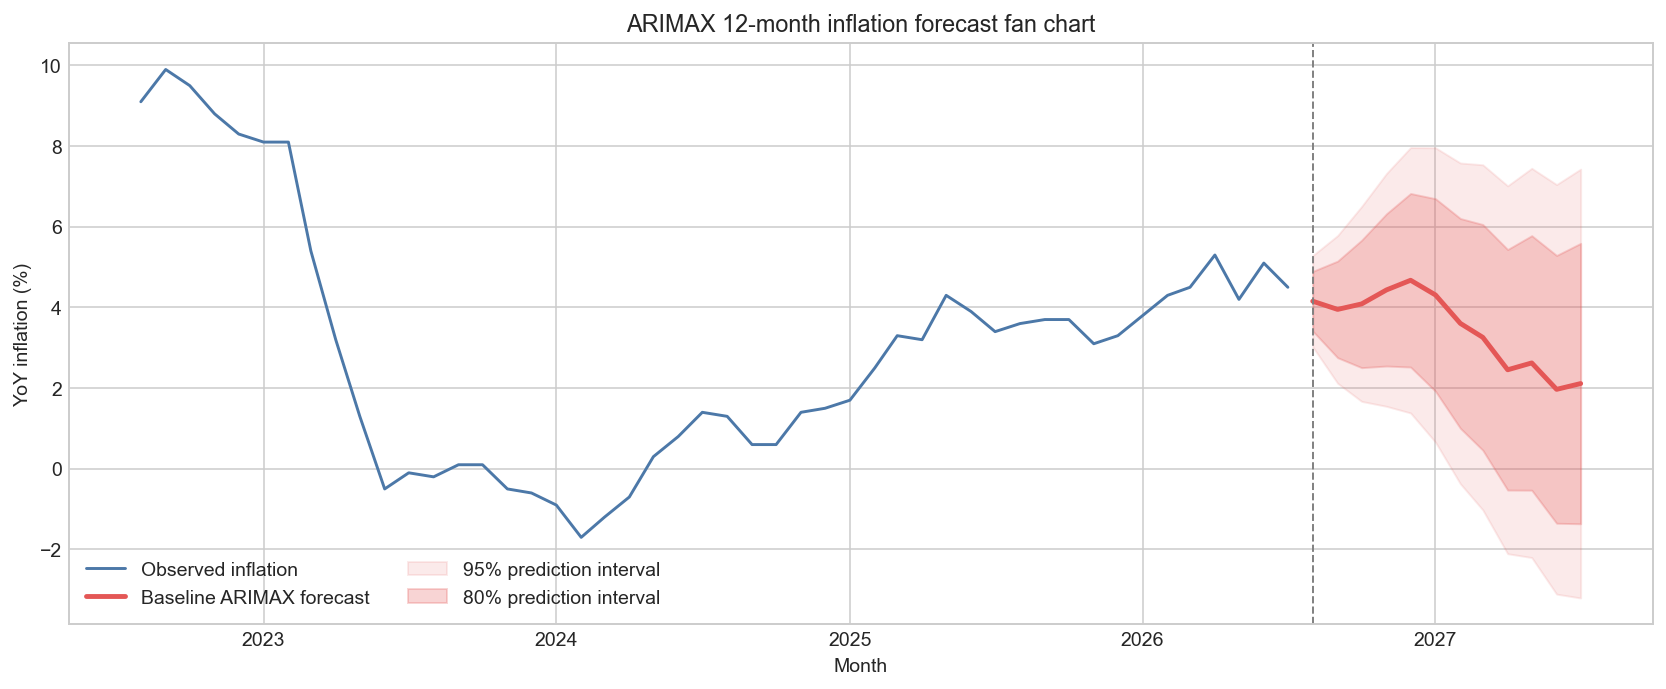

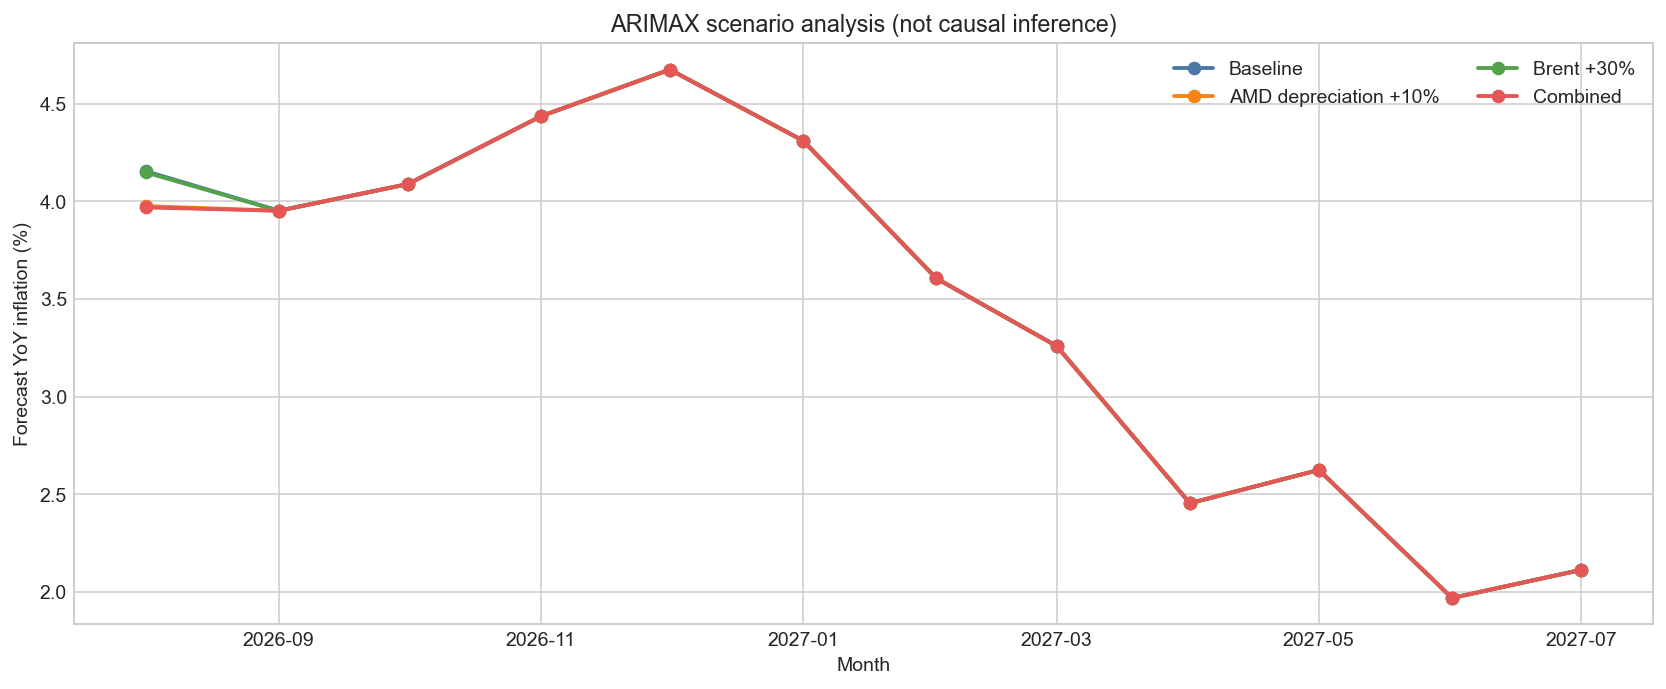

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(full_y.index[-48:], full_y.iloc[-48:], color='#4C78A8', label='Observed inflation')
ax.plot(baseline_fc.index, baseline_fc, color='#E45756', lw=2.5, label='Baseline ARIMAX forecast')
ax.fill_between(baseline_fc.index, baseline_ci95.iloc[:, 0].astype(float), baseline_ci95.iloc[:, 1].astype(float), color='#E45756', alpha=0.12, label='95% prediction interval')
ax.fill_between(baseline_fc.index, baseline_ci80.iloc[:, 0].astype(float), baseline_ci80.iloc[:, 1].astype(float), color='#E45756', alpha=0.25, label='80% prediction interval')
ax.axvline(future_idx.min(), color='grey', ls='--', lw=1)
ax.set(title='ARIMAX 12-month inflation forecast fan chart', ylabel='YoY inflation (%)', xlabel='Month')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / 'arimax_fan_chart.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for col, color in [('Baseline', '#4C78A8'), ('AMD depreciation +10%', '#F58518'), ('Brent +30%', '#54A24B'), ('Combined', '#E45756')]:
    ax.plot(scenario_table.index, scenario_table[col], marker='o', lw=2, label=col, color=color)
ax.set(title='ARIMAX scenario analysis (not causal inference)', ylabel='Forecast YoY inflation (%)', xlabel='Month')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / 'arimax_scenarios.png', dpi=180, bbox_inches='tight')
plt.show()

## Takeaways and limitations

This notebook reports results as predictive associations. It does **not** interpret ARIMAX coefficients or scenario responses causally. Scenario analysis mechanically applies specified exogenous paths within the estimated conditional forecasting model.

### Limitations

* Historical macroeconomic data may be revised.
* The analysis has no real-time vintage dataset.
* The policy rate is endogenous to inflation and other macroeconomic conditions.
* ARIMAX coefficients and scenarios do not establish causality.
* The model includes only a small set of macroeconomic variables.
* Structural breaks can destabilize estimated relationships.
* Backtests condition on realized future exogenous variables; real-time deployment requires forecasts or assumptions for them.
* `D_oil_2026` has no within-training variation in the 2011-02—2024-07 estimation sample, so its fixed-test coefficient is not identified; its reported standard error and p-value should not be interpreted.


In [ ]:
results = {
    'selected_sarima_order': str(SARIMA_ORDER),
    'selected_seasonal_order': str(SARIMA_SEASONAL_ORDER),
    'fixed_test_scores': comparison.round(6).to_dict(orient='index'),
    'rolling_origin_scores': rolling_summary.round(6).to_dict(orient='index'),
    'dm_tests': dm_results.round(6).to_dict(orient='records'),
    'forecast_intervals': forecast_intervals.round(6).rename_axis('month').reset_index().assign(month=lambda x: x['month'].astype(str)).to_dict(orient='records')
}
with open(OUTPUT_DIR / 'results.json', 'w') as f:
    json.dump(results, f, indent=2, default=str)